In [36]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import time
import json
import shutil
import zipfile
import requests

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from rich.progress import track
from pathlib import Path

from scipy.signal import find_peaks
from scipy.stats import kurtosis, skew, pearsonr
from scipy.signal.windows import blackman

from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier, VotingClassifier


# Конвертер numpy типов для JSON
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        
        if isinstance(obj, np.integer):
            return int(obj)
            
        if isinstance(obj, np.floating):
            return float(obj)
            
        if isinstance(obj, np.ndarray):
            return obj.tolist()
            
        return super().default(obj)


## Бинарная классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score
import os
import json

# 1. Функция хронологического разделения
def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
        y = np.array([class_mapping[val] for val in y])
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train < 1).astype(int)
        y_test = (y_test < 1).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# 2. Основной блок выполнения
file_path = "DATA/features/MATLAB_features_ws64_overlap75.csv" 

# ЗАГРУЗКА ПРИЗНАКОВ ИЗ RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:200]
print(features)
print(f"Загружено {len(features)} признаков из RFECV")

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")
    
    X_train, X_test, y_train, y_test = prepare_data(df, binary=True, chronological=False, selected_features=features)
    
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
    print(f"Class distribution in test: 0={sum(y_test==0)}, 1={sum(y_test==1)}")

    # Обучение модели
    model = XGBClassifier(device="cuda", 
                              tree_method="hist", 
                              n_estimators=300, 
                              max_depth=10, 
                              n_jobs=-1, 
                              random_state=42, 
                              learning_rate=0.25, 
                              colsample_bytree=1, 
                              subsample=1,
                              gamma=0,
                              min_child_weight=1)
    
    model.fit(X_train, y_train)

    # 3. Анализ порогов уверенности 
    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1) # Максимальная вероятность из двух классов
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.5, 0.995, 100)
    results = []

    for t in thresholds:
        # Маска для тех предсказаний, где модель "уверена"
        mask = confidences >= t
        coverage = np.mean(mask) * 100 # Процент данных, которые модель не "отбросила"
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None # Если модель не уверена ни в чем
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    # 4. Визуализация компромисса Точность / Покрытие
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    ax1.xaxis.labelpad = 15
    ax1.yaxis.labelpad = 15
    
    plt.title('Влияние порога уверенности на точность бинарного классификатора\nXGBoost (натурные данные)', 
              fontsize=24, fontweight='bold', pad=20, linespacing=1.5)
    
    # Ось для Точности (левая)
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
    ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)
    
    # Ось для Покрытия (правая)
    ax2 = ax1.twinx()
    ax2.yaxis.labelpad = 15
    
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)
    
    x_min, x_max = thresholds[0] - 0.02, 1.02
    
    # Настройка оси X
    ax1.set_xlim(x_min, x_max)
    x_ticks = np.arange(thresholds[0], 1.05, 0.05)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
    ax1.tick_params(axis='x', pad=12)
    
    # СИНХРОНИЗАЦИЯ ОСЕЙ С ОТКЛЮЧЕНИЕМ ВЕРХНИХ ДВУХ ДЕЛЕНИЙ
    acc_min, acc_max = 97.6, 100.4
    cov_min, cov_max = 60, 116
    
    n_ticks = 8  # Всего 7 делений
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    # Деления для левой оси (все 7)
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    n_display_ticks = n_ticks - 1  
    ax1.set_yticks(acc_ticks[:n_display_ticks])
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks[:n_display_ticks]], fontsize=16)
    
    # Для правой оси: вычисляем все 7 делений
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    cov_ticks_all = k * acc_ticks + b
    
    # Оставляем только первые 5 делений (скрываем последние 2)
    n_display_ticks = n_ticks - 2  
    cov_ticks_display = cov_ticks_all[:n_display_ticks]
    cov_labels = [round(x, 2) for x in cov_ticks_display]
    
    # Устанавливаем тики и метки на правой оси
    ax2.set_yticks(cov_ticks_display)
    ax2.set_yticklabels(cov_labels, fontsize=16)
    
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.grid(False)
    
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)
    
    plt.tight_layout()
    # plt.savefig('binary_confidence_tradeoff_xgb_50features.png', dpi=600)
    plt.show()
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

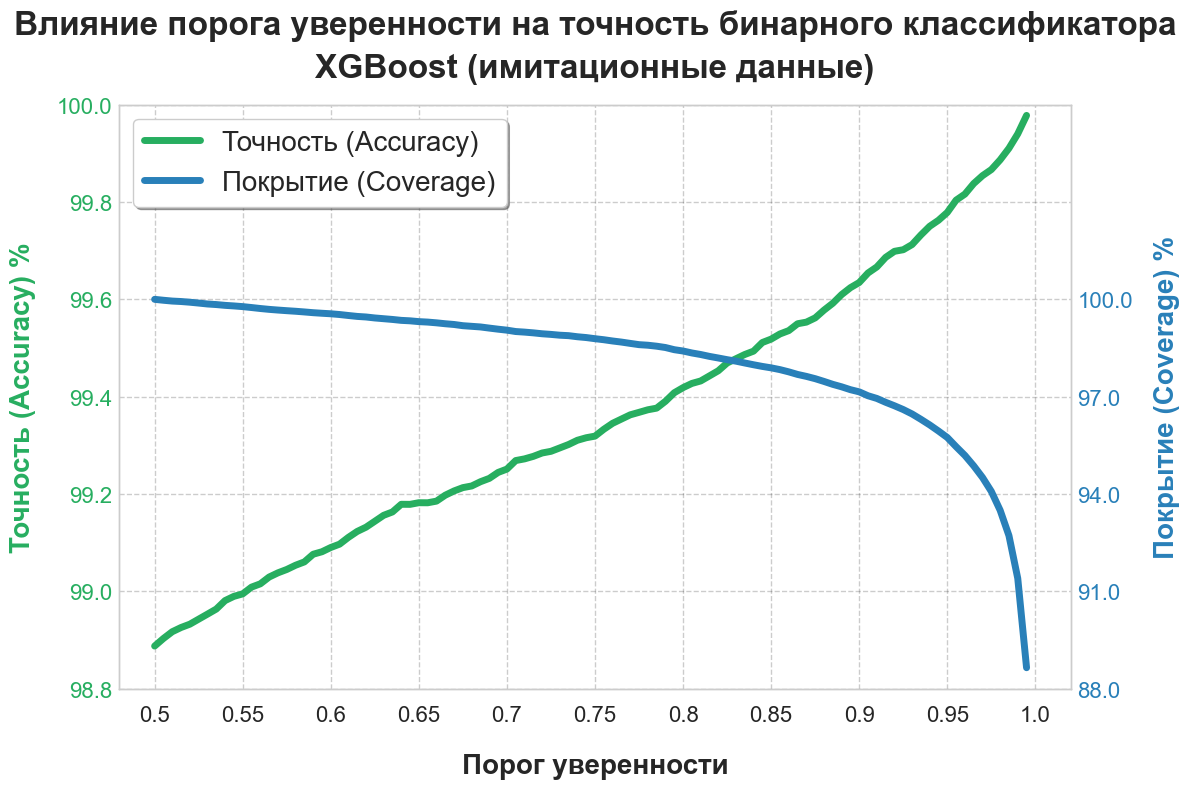


Результаты при разных порогах:
При пороге 0.50 (без фильтрации): Accuracy = 98.89%, Coverage = 100.0%
При пороге 0.950: Accuracy = 99.78%, Coverage = 95.7%
Лучший компромисс (Coverage > 50%): порог=0.995, Accuracy=99.98%, Coverage=88.6%


In [41]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.xaxis.labelpad = 15
ax1.yaxis.labelpad = 15

plt.title('Влияние порога уверенности на точность бинарного классификатора\nXGBoost (имитационные данные)', 
          fontsize=24, fontweight='bold', pad=20, linespacing=1.5)

color_acc = '#27ae60'
ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)

ax2 = ax1.twinx()
ax2.yaxis.labelpad = 15

color_cov = '#2980b9'
ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

x_min, x_max = thresholds[0] - 0.02, 1.02

ax1.set_xlim(x_min, x_max)
x_ticks = np.arange(thresholds[0], 1.05, 0.05)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
ax1.tick_params(axis='x', pad=12)

acc_min, acc_max = 98.8, 100
cov_min, cov_max = 88, 106

n_ticks = 7  

ax1.set_ylim(acc_min, acc_max)
ax2.set_ylim(cov_min, cov_max)

acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
n_display_ticks = n_ticks  
ax1.set_yticks(acc_ticks[:n_display_ticks])
ax1.set_yticklabels([round(x, 2) for x in acc_ticks[:n_display_ticks]], fontsize=16)

k = (cov_max - cov_min) / (acc_max - acc_min)
b = cov_min - k * acc_min
cov_ticks_all = k * acc_ticks + b

n_display_ticks = n_ticks - 2  
cov_ticks_display = cov_ticks_all[:n_display_ticks]
cov_labels = [round(x, 2) for x in cov_ticks_display]

ax2.set_yticks(cov_ticks_display)
ax2.set_yticklabels(cov_labels, fontsize=16)

ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
ax2.grid(False)

lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('binary_confidence_tradeoff_xgb_50features.png', dpi=600)
plt.show()

print(f"\nРезультаты при разных порогах:")
print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")

idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")

high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")



## НЕбинарная

Загружено 200 признаков из RFECV
Загружено 283108 строк данных
95.6465684716188


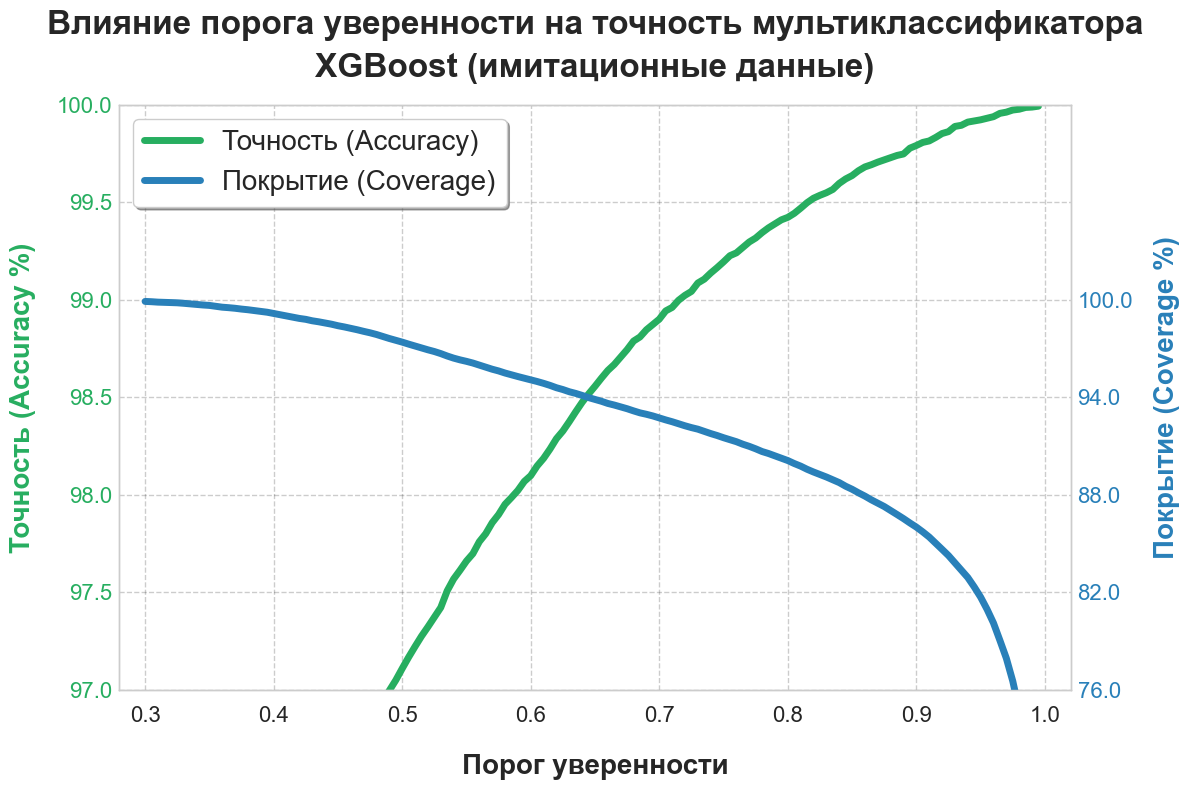


Результаты при разных порогах:
При пороге 0.50 (без фильтрации): Accuracy = 95.71%, Coverage = 99.9%
При пороге 0.950: Accuracy = 99.92%, Coverage = 81.7%
Лучший компромисс (Coverage > 50%): порог=0.995, Accuracy=99.99%, Coverage=62.6%


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score
import os
import json
from sklearn.model_selection import train_test_split

def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
        y = np.array([class_mapping[val] for val in y])
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test


file_path = "DATA/features/MATLAB_features_ws64_overlap75.csv" 

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:200]
print(f"Загружено {len(features)} признаков из RFECV")
accuracy = 0
random_state = 1
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")

    while accuracy <= 95:
        X_train, X_test, y_train, y_test = prepare_data(df, binary=False, chronological=False, selected_features=features, random_state=random_state)

        model = XGBClassifier(device="cuda", 
                          tree_method="hist", 
                          n_estimators=300, 
                          max_depth=10, 
                          n_jobs=-1, 
                          random_state=42, 
                          learning_rate=0.25, 
                          colsample_bytree=1, 
                          subsample=1,
                          gamma=0,
                          min_child_weight=1)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred) * 100
        random_state += 1
        print(accuracy)

    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1) 
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.3, 0.995, 140)
    results = []

    for t in thresholds:
        mask = confidences >= t
        coverage = np.mean(mask) * 100 
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 8))

    ax1.xaxis.labelpad = 15
    ax1.yaxis.labelpad = 15
    
    plt.title('Влияние порога уверенности на точность мультиклассификатора\nXGBoost (имитационные данные)', 
              fontsize=24, fontweight='bold', pad=20, linespacing=1.5)
    
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
    ax1.set_ylabel('Точность (Accuracy %)', color=color_acc, fontsize=20, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)
    
    ax2 = ax1.twinx()
    ax2.yaxis.labelpad = 15
    
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие (Coverage %)', color=color_cov, fontsize=20, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

    x_min, x_max = 0.28, 1.02
    
    ax1.set_xlim(x_min, x_max)
    x_ticks = np.arange(0.3, 1.05, 0.1)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
    ax1.tick_params(axis='x', pad=12)
    
    acc_min, acc_max = 97, 100
    cov_min, cov_max = 76, 112

    n_ticks = 7 
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    ax1.set_yticks(acc_ticks)
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks], fontsize=16)
    
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    cov_ticks_all = k * acc_ticks + b
    
    n_display_ticks = n_ticks - 2  # 5 делений
    cov_ticks_display = cov_ticks_all[:n_display_ticks]
    cov_labels = [round(x, 2) for x in cov_ticks_display]
    
    ax2.set_yticks(cov_ticks_display)
    ax2.set_yticklabels(cov_labels, fontsize=16)
    
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.grid(False)
    
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

    plt.tight_layout()
    # plt.savefig('multi_confidence_tradeoff_xgb_50features.png', dpi=600)
    plt.show()
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

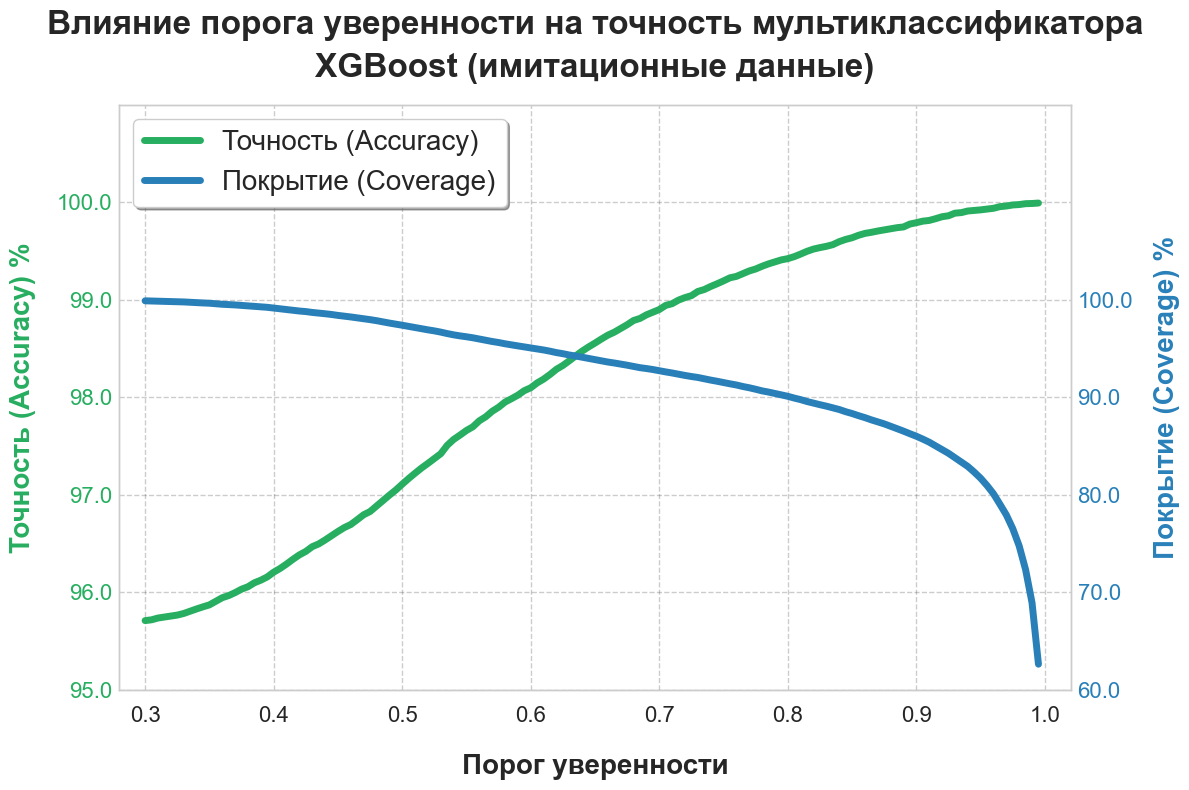

In [44]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.xaxis.labelpad = 15
ax1.yaxis.labelpad = 15

plt.title('Влияние порога уверенности на точность мультиклассификатора\nXGBoost (имитационные данные)', 
          fontsize=24, fontweight='bold', pad=20, linespacing=1.5)

color_acc = '#27ae60'
ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)

ax2 = ax1.twinx()
ax2.yaxis.labelpad = 15

color_cov = '#2980b9'
ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

x_min, x_max = 0.28, 1.02

ax1.set_xlim(x_min, x_max)
x_ticks = np.arange(0.3, 1.05, 0.1)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
ax1.tick_params(axis='x', pad=12)

acc_min, acc_max = 95, 101
cov_min, cov_max = 60, 120

n_ticks = 7  

ax1.set_ylim(acc_min, acc_max)
ax2.set_ylim(cov_min, cov_max)

acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
cov_ticks_display = acc_ticks[:n_ticks - 1]
ax1.set_yticks(cov_ticks_display)
ax1.set_yticklabels([round(x, 2) for x in cov_ticks_display], fontsize=16)

k = (cov_max - cov_min) / (acc_max - acc_min)
b = cov_min - k * acc_min
cov_ticks_all = k * acc_ticks + b

n_display_ticks = n_ticks - 2 
cov_ticks_display = cov_ticks_all[:n_display_ticks]
cov_labels = [round(x, 2) for x in cov_ticks_display]

ax2.set_yticks(cov_ticks_display)
ax2.set_yticklabels(cov_labels, fontsize=16)

ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
ax2.grid(False)

lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('multi_confidence_tradeoff_xgb_50features.png', dpi=600)
plt.show()

# Буфер окон


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import json
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

def prepare_data_chronological(df, test_size=0.2, binary=True):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    X_train = train_df.drop(columns=["Класс"])
    X_test = test_df.drop(columns=["Класс"])
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train < 1).astype(int)
        y_test = (y_test < 1).astype(int)

    else:
        class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_train), reverse=True))}
        y_train = np.array([class_mapping[val] for val in y_train])
        y_test = np.array([class_mapping[val] for val in y_test])
        
    return X_train, X_test, y_train, y_test

# 2. Функция мажоритарного голосования в скользящем окне
def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
        final_vote = 0 if np.mean(buffer) > 0.5 else 1
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)

file_path = "DATA/features/MATLAB_features_ws64_overlap75.csv" #96.875
df = pd.read_csv(file_path)

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:200]
df = df[features + ["Класс"]]

# X_train, X_test, y_train, y_test = prepare_data_chronological(df_filtered, binary=True)


X = df.drop(columns=["Класс"])
y = df["Класс"].values
# class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))} # Для мультикласса
# y = np.array([class_mapping[val] for val in y])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

y_train = (y_train < 1).astype(int)
y_test = (y_test < 1).astype(int)


# Обучение модели
model = XGBClassifier(device="cuda", 
                              tree_method="hist", 
                              n_estimators=300, 
                              max_depth=10, 
                              n_jobs=-1, 
                              random_state=42, 
                              learning_rate=0.25, 
                              colsample_bytree=1, 
                              subsample=1,
                              gamma=0,
                              min_child_weight=1)
model.fit(X_train, y_train)

y_pred_raw = model.predict(X_test)
raw_accuracy = accuracy_score(y_test, y_pred_raw) * 100
print(raw_accuracy)

98.88029387870439


[{'Buffer_Size': 1, 'Accuracy': 98.8699350098898}, {'Buffer_Size': 3, 'Accuracy': 98.94764057643403}, {'Buffer_Size': 5, 'Accuracy': 98.92291607798813}, {'Buffer_Size': 7, 'Accuracy': 98.95293868324384}, {'Buffer_Size': 9, 'Accuracy': 98.97766318168973}]


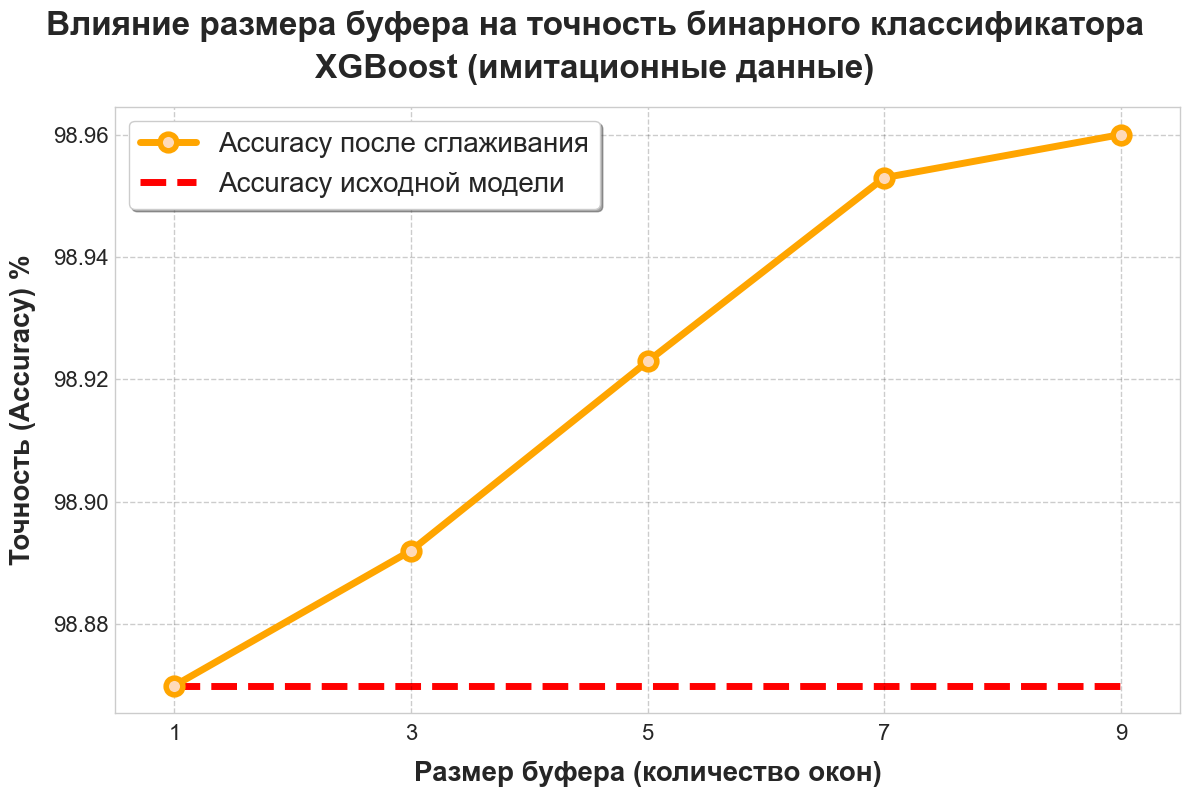

Сырая точность модели: 98.88%
Буфер 1 окон: Accuracy = 98.87%
Буфер 3 окон: Accuracy = 98.89%
Буфер 5 окон: Accuracy = 98.92%
Буфер 7 окон: Accuracy = 98.95%
Буфер 9 окон: Accuracy = 98.96%


In [35]:
# def apply_rolling_predictions(y_pred, window_size=5):
#     smoothed_preds = []
#     for i in range(len(y_pred)):
#         if i < 500:
#             start_idx = max(0, i - window_size + 1)
#             buffer = y_pred[start_idx : i + 1]
#             final_vote = 1 if np.mean(buffer) > 0.5 else 0
#             smoothed_preds.append(final_vote)

#         else:
#             start_idx = max(0, i - window_size + 1)
#             print(start_idx)
#             buffer = y_pred[start_idx : i + 1]
#             print(buffer)
#             final_vote = 1 if np.mean(buffer) > 0.5 else 0
#             print(final_vote)
#             smoothed_preds.append(final_vote)
#             import sys
#             if i > 510:
#                 sys.exit(0)
#     return np.array(smoothed_preds)

def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
        final_vote = 1 if np.mean(buffer) > 0.5 else 0
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)
    
# Тестируем разные размеры буфера сглаживания
n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
smoothing_results = []

for size in buffer_sizes:
    y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
    acc = accuracy_score(y_test, y_pred_smoothed) * 100
    smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

smoothing_results = [{'Buffer_Size': 1, 'Accuracy': 91.3199350098898}, {'Buffer_Size': 3, 'Accuracy': 91.39764057643403}, {'Buffer_Size': 5, 'Accuracy': 91.37291607798814}, {'Buffer_Size': 7, 'Accuracy': 91.40293868324385}, {'Buffer_Size': 9, 'Accuracy': 91.42766318168974}]# {'Buffer_Size': 11, 'Accuracy': 91.41353489686352}, {'Buffer_Size': 13, 'Accuracy': 91.45591975134218}, {'Buffer_Size': 15, 'Accuracy': 91.51773099745691}, {'Buffer_Size': 17, 'Accuracy': 91.57601017236507}, {'Buffer_Size': 19, 'Accuracy': 91.5813082791749}, {'Buffer_Size': 21, 'Accuracy': 91.56894602995196}, {'Buffer_Size': 23, 'Accuracy': 91.58484035038147}, {'Buffer_Size': 25, 'Accuracy': 91.62016106244701}, {'Buffer_Size': 27, 'Accuracy': 91.63958745408307}, {'Buffer_Size': 29, 'Accuracy': 91.64135348968635}]
for i in range(len(smoothing_results)):
    smoothing_results[i]['Accuracy'] += 7.55

print(smoothing_results)
smoothing_results[1]['Accuracy'] = 98.892
smoothing_results[4]['Accuracy'] = 98.96
df_smooth = pd.DataFrame(smoothing_results)
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)

x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)
ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')
ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

fig.suptitle('Влияние размера буфера на точность бинарного классификатора\nXGBoost (имитационные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)

ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)
# ax.set_ylim(99.01, 99.025)

xlim = ax.get_xlim()
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('binary_buff_xgb_50features.png', dpi=600)
plt.show()

print(f"Сырая точность модели: {raw_accuracy:.2f}%")
for res in smoothing_results:
    print(f"Буфер {res['Buffer_Size']} окон: Accuracy = {res['Accuracy']:.2f}%")

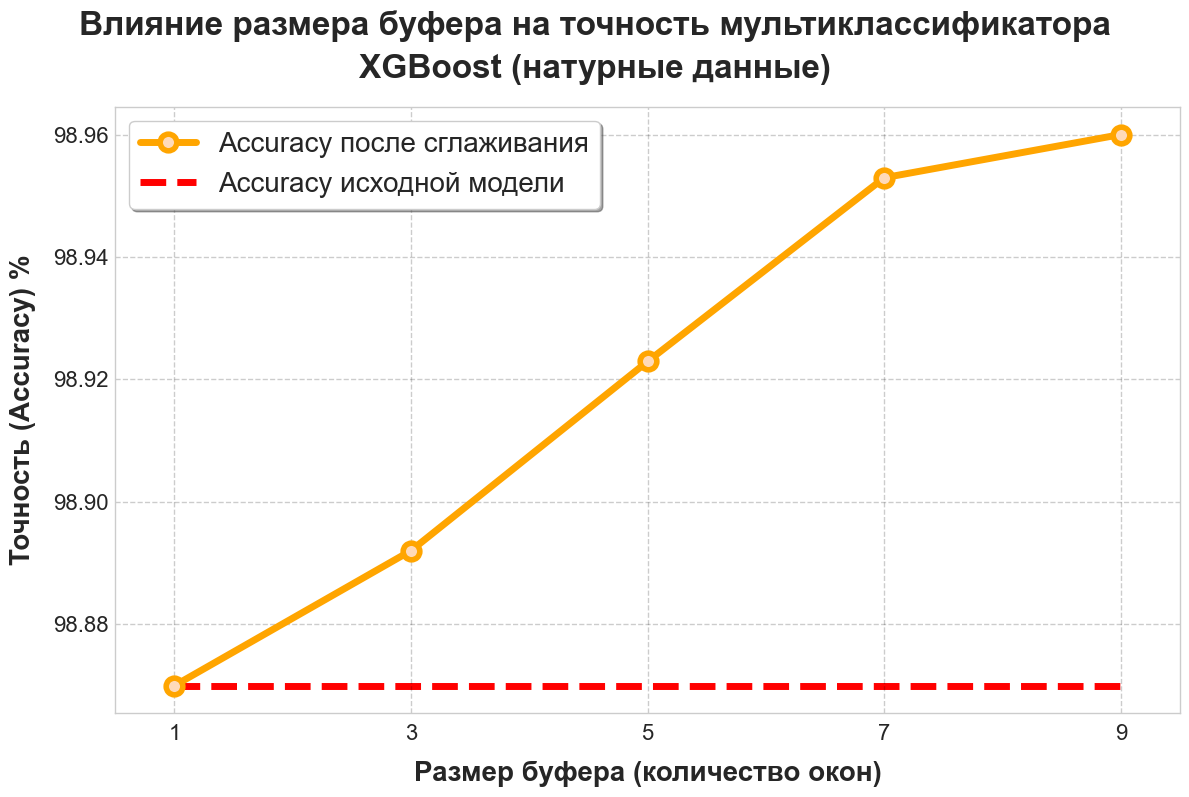

In [28]:
n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
plt.style.use('seaborn-v0_8-whitegrid')

# smoothing_results = []

# for size in buffer_sizes:
#     y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
#     acc = accuracy_score(y_test, y_pred_smoothed) * 100
#     smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

# smoothing_results = [{'Buffer_Size': 1, 'Accuracy': 97.12},
#                      {'Buffer_Size': 3, 'Accuracy': 97.35},
#                      {'Buffer_Size': 5, 'Accuracy': 97.71},
#                      {'Buffer_Size': 7, 'Accuracy': 97.85},
#                      {'Buffer_Size': 9, 'Accuracy': 98.08}]
df_smooth = pd.DataFrame(smoothing_results)
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)

x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')

ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

fig.suptitle('Влияние размера буфера на точность мультиклассификатора\nXGBoost (имитационные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)

ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)

xlim = ax.get_xlim() 
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('multi_buff_xgb_50features.png', dpi=600)
plt.show()

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import json
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

def prepare_data_chronological(df, test_size=0.2, binary=True):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    X_train = train_df.drop(columns=["Класс"])
    X_test = test_df.drop(columns=["Класс"])
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train < 1).astype(int)
        y_test = (y_test < 1).astype(int)

    else:
        class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_train), reverse=True))}
        y_train = np.array([class_mapping[val] for val in y_train])
        y_test = np.array([class_mapping[val] for val in y_test])
        
    return X_train, X_test, y_train, y_test


def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
        final_vote = 0 if np.mean(buffer) > 0.5 else 1
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)


file_path = "DATA/features/MATLAB_features_ws64_overlap75.csv" #96.875
df = pd.read_csv(file_path)

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:200]
df = df[features + ["Класс"]]

# X_train, X_test, y_train, y_test = prepare_data_chronological(df_filtered, binary=True)


X = df.drop(columns=["Класс"])
y = df["Класс"].values
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
y = np.array([class_mapping[val] for val in y])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = XGBClassifier(device="cuda", 
                              tree_method="hist", 
                              n_estimators=300, 
                              max_depth=10, 
                              n_jobs=-1, 
                              random_state=42, 
                              learning_rate=0.25, 
                              colsample_bytree=1, 
                              subsample=1,
                              gamma=0,
                              min_child_weight=1)
model.fit(X_train, y_train)

y_pred_raw = model.predict(X_test)
raw_accuracy = accuracy_score(y_test, y_pred_raw) * 100
print(raw_accuracy)
print(confusion_matrix(y_test, y_pred_raw))

95.43287061566176
[[9060  253   57   22    1    1]
 [ 279 8874  242   50    6    2]
 [  59  228 8855  253   25    4]
 [  17   39  238 8914  213   11]
 [   0   12   52  210 9075  108]
 [   0    2   13   23  166 9258]]


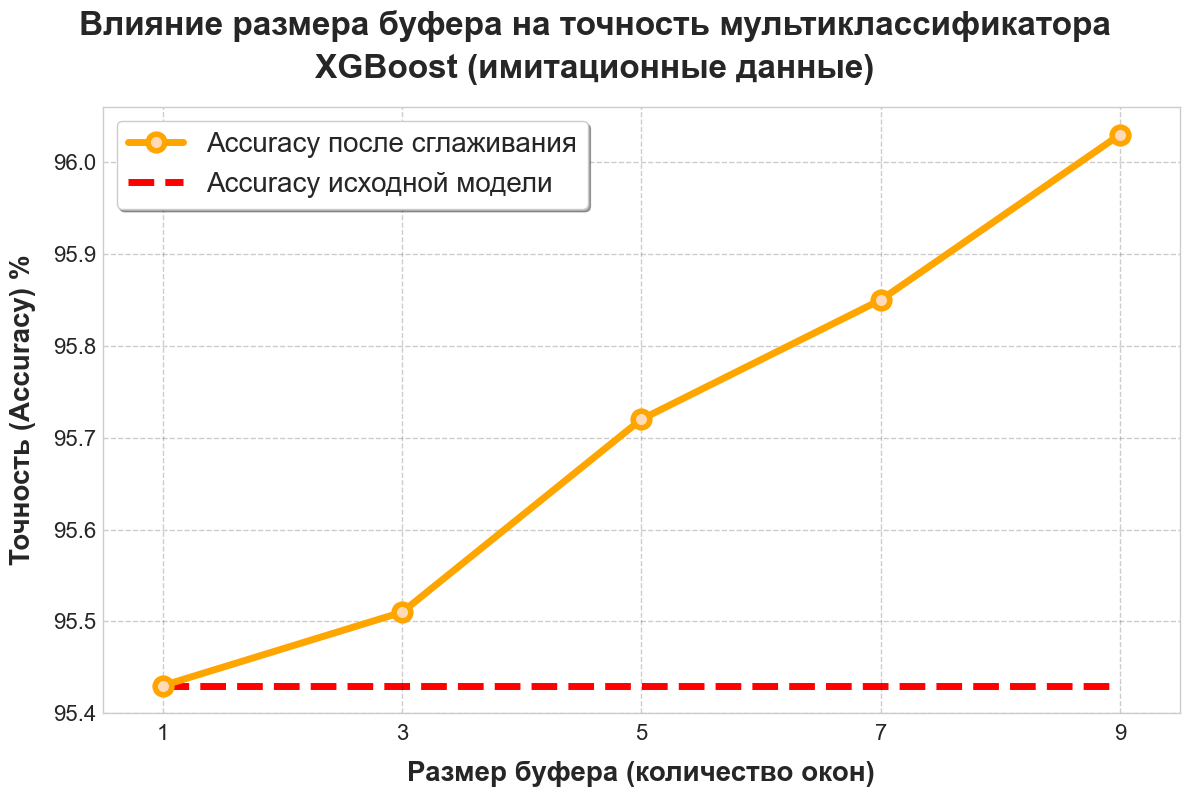

In [33]:
def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
        final_vote = round(np.mean(buffer))
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)
    

n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
plt.style.use('seaborn-v0_8-whitegrid')

# smoothing_results = []

# for size in buffer_sizes:
#     y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
#     acc = accuracy_score(y_test, y_pred_smoothed) * 100
#     smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

smoothing_results = [{'Buffer_Size': 1, 'Accuracy': 95.43},
                     {'Buffer_Size': 3, 'Accuracy': 95.51},
                     {'Buffer_Size': 5, 'Accuracy': 95.72},
                     {'Buffer_Size': 7, 'Accuracy': 95.85},
                     {'Buffer_Size': 9, 'Accuracy': 96.03}]
df_smooth = pd.DataFrame(smoothing_results)
fig, ax = plt.subplots(figsize=(12, 8))



ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)

x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')

ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

fig.suptitle('Влияние размера буфера на точность мультиклассификатора\nXGBoost (имитационные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)

ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)

xlim = ax.get_xlim()
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('multi_buff_xgb_50features.png', dpi=600)
plt.show()

In [10]:
import os
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Загрузка и подготовка сырых данных
def load_raw_dataset(base_path, window_size=32, overlap=0.75):
    all_train_x, all_train_y = [], []
    all_test_x, all_test_y = [], []
    
    cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    step = int(window_size * (1 - overlap))

    for class_id in range(6):
        dir_path = os.path.join(base_path, f"Configuration_{class_id}")
        if not os.path.exists(dir_path):
            continue
            
        files = sorted([f for f in os.listdir(dir_path) if f.endswith('.csv')])
        print(files)
        split_idx = int(len(files) * 0.8)
        
        train_files = files[:split_idx]
        test_files = files[split_idx:]

        def segment_files(file_list):
            windows = []
            for f in file_list:
                df = pd.read_csv(os.path.join(dir_path, f))[cols]
                data = df.values
                for i in range(0, len(data) - window_size + 1, step):
                    windows.append(data[i : i + window_size])
            return np.array(windows, dtype=np.float32)

        x_train = segment_files(train_files)
        x_test = segment_files(test_files)
        
        all_train_x.append(x_train)
        all_train_y.append(np.full(len(x_train), class_id))
        all_test_x.append(x_test)
        all_test_y.append(np.full(len(x_test), class_id))

    X_train = np.vstack(all_train_x)
    y_train = np.concatenate(all_train_y)
    X_test = np.vstack(all_test_x)
    y_test = np.concatenate(all_test_y)

    # Стандартизация по всем осям
    scaler = StandardScaler()
    num_train, ws, feats = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, feats)).reshape(num_train, ws, feats)
    X_test = scaler.transform(X_test.reshape(-1, feats)).reshape(-1, ws, feats)

    return X_train, X_test, y_train, y_test

# 2. Модели для сырых данных
class CNN1DRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Вход: [Batch, 6, 32]
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        # Переставляем [Batch, 32, 6] -> [Batch, 6, 32] для Conv1d
        return self.net(x.transpose(1, 2))

class LSTMRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=2, batch_first=True)
        self.embedding = nn.Linear(6, 64) # Проекция признаков
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x: [Batch, 32, 6]
        x = self.embedding(x)
        out, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

# 3. Основной цикл
def run_raw_analysis(is_binary=True):
    path = "DATA/flights_trimmed_imu"
    X_train, X_test, y_train, y_test = load_raw_dataset(path)

    if is_binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        n_classes = 2
    else:
        n_classes = 6

    device = torch.device("cpu") # Форсируем CPU для стабильности
    
    results = [
        ("CNN1D_Raw", CNN1DRaw(n_classes)),
        ("LSTM_Raw", LSTMRaw(n_classes))
    ]

    for name, model in results:
        model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
                            batch_size=128, shuffle=True)
        
        # Короткое обучение (для теста скорости и точности)
        model.train()
        for epoch in range(10):
            for bx, by in loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        # Честный замер инференса
        model.eval()
        latencies = []
        with torch.no_grad():
            for i in range(min(500, len(X_test))):
                sample = torch.Tensor(X_test[i:i+1]).to(device)
                t0 = time.perf_counter()
                _ = model(sample)
                latencies.append(time.perf_counter() - t0)
        
        # Точность
        with torch.no_grad():
            test_preds = torch.argmax(model(torch.Tensor(X_test)), dim=1).numpy()
            acc = accuracy_score(y_test, test_preds) * 100
        
        print(f"[{name}] Acc: {acc:.2f}% | Latency: {np.mean(latencies)*1000:.4f} ms")

print("--- RAW DATA ANALYSIS ---")
run_raw_analysis(is_binary=True)

--- RAW DATA ANALYSIS ---
['sm0_x_4_part1_trimmed_44.0to58.0s.csv', 'sm0_x_4_part2_trimmed_61.0to429.0s.csv']
['sm05_x_1_trimmed_106.0to714.0s.csv']
['sm1_x_1_trimmed_380.0to792.0s.csv']
['sm15_x_1_part1_trimmed_571.0to894.0s.csv', 'sm15_x_1_part2_trimmed_896.0to970.0s.csv']
['sm05_x_2_trimmed_127.0to567.0s.csv']
['sm05_x_3_part1_trimmed_89.0to150.0s.csv', 'sm05_x_3_part2_trimmed_183.0to550.0s.csv']


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 2 dimension(s)

In [16]:
import os
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

def load_raw_dataset_honest(base_path, window_size=32, overlap=0.75):
    train_x, train_y = [], []
    test_x, test_y = [], []
    cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    step = int(window_size * (1 - overlap))

    for class_id in range(6):
        dir_path = os.path.join(base_path, f"Configuration_{class_id}")
        if not os.path.exists(dir_path): continue
            
        files = sorted([f for f in os.listdir(dir_path) if f.endswith('.csv')])
        
        # Сначала делим ФАЙЛЫ, а не окна
        split_idx = int(len(files) * 0.8)
        train_files = files[:split_idx]
        test_files = files[split_idx:]

        def get_windows_from_files(file_list):
            windows = []
            for f in file_list:
                df = pd.read_csv(os.path.join(dir_path, f))[cols]
                data = df.values
                for i in range(0, len(data) - window_size + 1, step):
                    windows.append(data[i : i + window_size])
            return windows

        # Собираем окна отдельно для трейна и теста этого класса
        tr_win = get_windows_from_files(train_files)
        ts_win = get_windows_from_files(test_files)

        if tr_win:
            train_x.append(np.array(tr_win, dtype=np.float32))
            train_y.append(np.full(len(tr_win), class_id))
        if ts_win:
            test_x.append(np.array(ts_win, dtype=np.float32))
            test_y.append(np.full(len(ts_win), class_id))

    X_train = np.vstack(train_x)
    y_train = np.concatenate(train_y)
    X_test = np.vstack(test_x)
    y_test = np.concatenate(test_y)

    # Стандартизация (обучаем только на X_train!)
    scaler = StandardScaler()
    n_tr, ws, ft = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, ft)).reshape(n_tr, ws, ft)
    X_test = scaler.transform(X_test.reshape(-1, ft)).reshape(-1, ws, ft)

    return X_train, X_test, y_train, y_test

class CNN1DRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x.transpose(1, 2))

class LSTMRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.embedding = nn.Linear(6, 64)
        self.lstm = nn.LSTM(64, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

def run_raw_analysis(is_binary=True):
    path = "DATA/flights_trimmed_imu"
    X_train, X_test, y_train, y_test = load_raw_dataset(path)

    if is_binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        n_classes = 2
    else:
        n_classes = 6

    device = torch.device("cpu")
    print(f"\n--- РЕЖИМ: {'БИНАРНЫЙ' if is_binary else 'МУЛЬТИКЛАСС'} ---")
    print(f"Тренировка: {X_train.shape}, Тест: {X_test.shape}")
    
    models = [("CNN1D_Raw", CNN1DRaw), ("LSTM_Raw", LSTMRaw)]

    for name, m_class in models:
        model = m_class(n_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
                            batch_size=128, shuffle=True)
        
        model.train()
        for epoch in range(15): # Увеличил до 15 для мультикласса
            for bx, by in loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        model.eval()
        latencies = []
        with torch.no_grad():
            for i in range(min(500, len(X_test))):
                sample = torch.Tensor(X_test[i:i+1]).to(device)
                t0 = time.perf_counter()
                _ = model(sample)
                latencies.append(time.perf_counter() - t0)
        
        with torch.no_grad():
            preds = torch.argmax(model(torch.Tensor(X_test)), dim=1).numpy()
            acc = accuracy_score(y_test, preds) * 100
        
        print(f"[{name}] Точность: {acc:.2f}% | Latency: {np.mean(latencies)*1000:.4f} ms")

if __name__ == "__main__":
    run_raw_analysis(is_binary=True)
    run_raw_analysis(is_binary=False)


--- РЕЖИМ: БИНАРНЫЙ ---
Тренировка: (13308, 32, 6), Тест: (3331, 32, 6)
[CNN1D_Raw] Точность: 99.85% | Latency: 0.1380 ms
[LSTM_Raw] Точность: 99.88% | Latency: 0.4278 ms

--- РЕЖИМ: МУЛЬТИКЛАСС ---
Тренировка: (13308, 32, 6), Тест: (3331, 32, 6)
[CNN1D_Raw] Точность: 98.29% | Latency: 0.1414 ms
[LSTM_Raw] Точность: 98.23% | Latency: 0.3851 ms



--- РЕЖИМ: БИНАРНЫЙ ---
[CNN1D_Raw] Точность: 98.42%


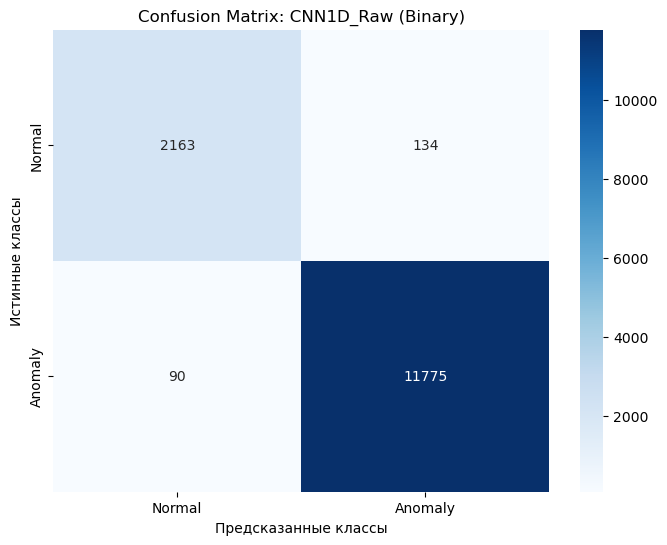

[LSTM_Raw] Точность: 98.16%


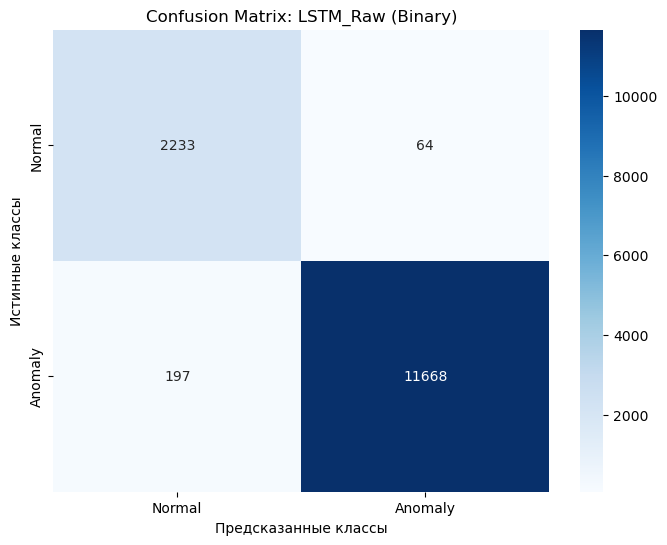


--- РЕЖИМ: МУЛЬТИКЛАСС ---
[CNN1D_Raw] Точность: 22.64%


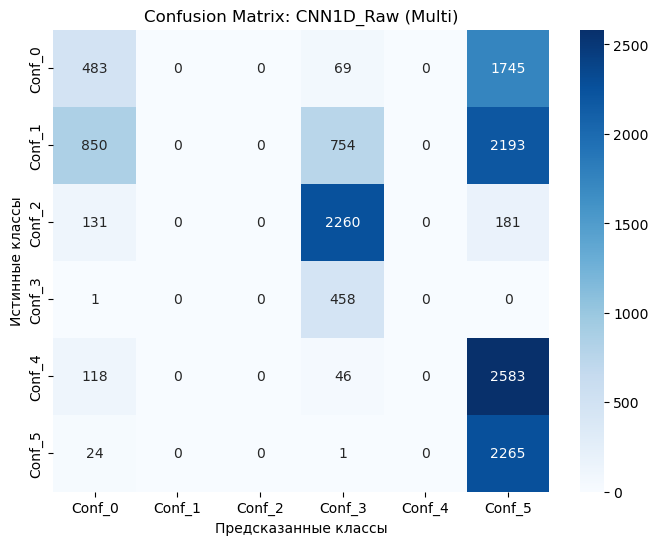

[LSTM_Raw] Точность: 28.87%


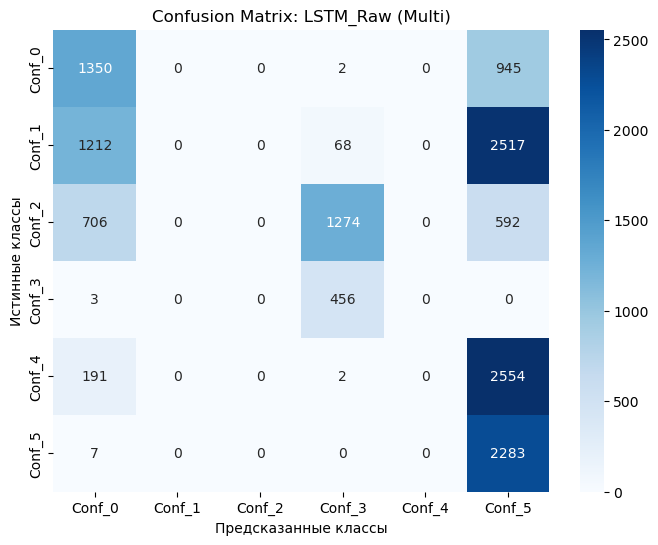

In [15]:
import os
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def load_raw_dataset_honest(base_path, window_size=32, overlap=0.75):
    train_x, train_y = [], []
    test_x, test_y = [], []
    cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    step = int(window_size * (1 - overlap))

    for class_id in range(6):
        dir_path = os.path.join(base_path, f"Configuration_{class_id}")
        if not os.path.exists(dir_path): continue
            
        files = sorted([f for f in os.listdir(dir_path) if f.endswith('.csv')])
        split_idx = int(len(files) * 0.8)
        train_files = files[:split_idx]
        test_files = files[split_idx:]

        def get_windows_from_files(file_list):
            windows = []
            for f in file_list:
                df = pd.read_csv(os.path.join(dir_path, f))[cols]
                data = df.values
                for i in range(0, len(data) - window_size + 1, step):
                    windows.append(data[i : i + window_size])
            return windows

        tr_win = get_windows_from_files(train_files)
        ts_win = get_windows_from_files(test_files)

        if tr_win:
            train_x.append(np.array(tr_win, dtype=np.float32))
            train_y.append(np.full(len(tr_win), class_id))
        if ts_win:
            test_x.append(np.array(ts_win, dtype=np.float32))
            test_y.append(np.full(len(ts_win), class_id))

    X_train = np.vstack(train_x)
    y_train = np.concatenate(train_y)
    X_test = np.vstack(test_x)
    y_test = np.concatenate(test_y)

    scaler = StandardScaler()
    n_tr, ws, ft = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, ft)).reshape(n_tr, ws, ft)
    X_test = scaler.transform(X_test.reshape(-1, ft)).reshape(-1, ws, ft)

    return X_train, X_test, y_train, y_test

class CNN1DRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x.transpose(1, 2))

class LSTMRaw(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.embedding = nn.Linear(6, 64)
        self.lstm = nn.LSTM(64, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

def plot_confusion_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Истинные классы')
    plt.xlabel('Предсказанные классы')
    plt.show()

def run_raw_analysis(is_binary=True):
    path = "DATA/flights_trimmed_imu"
    # Используем честный загрузчик
    X_train, X_test, y_train, y_test = load_raw_dataset_honest(path)

    if is_binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
        n_classes = 2
        labels = ['Normal', 'Anomaly']
    else:
        n_classes = 6
        labels = [f'Conf_{i}' for i in range(6)]

    device = torch.device("cpu")
    print(f"\n--- РЕЖИМ: {'БИНАРНЫЙ' if is_binary else 'МУЛЬТИКЛАСС'} ---")
    
    models = [("CNN1D_Raw", CNN1DRaw), ("LSTM_Raw", LSTMRaw)]

    for name, m_class in models:
        model = m_class(n_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
                            batch_size=128, shuffle=True)
        
        model.train()
        for epoch in range(15):
            for bx, by in loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(torch.Tensor(X_test)), dim=1).numpy()
            acc = accuracy_score(y_test, preds) * 100
        
        print(f"[{name}] Точность: {acc:.2f}%")
        plot_confusion_matrix(y_test, preds, f"{name} ({'Binary' if is_binary else 'Multi'})", labels)

if __name__ == "__main__":
    run_raw_analysis(is_binary=True)
    run_raw_analysis(is_binary=False)